# OCR 

## Import


In [2]:
# import 
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import struct
from pathlib import Path
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')


## data import


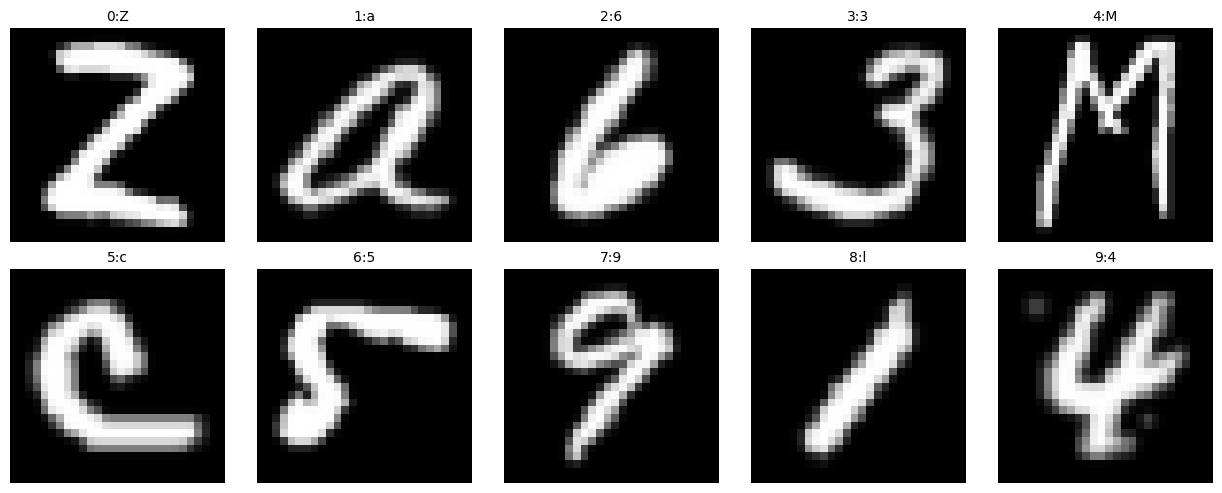

In [3]:
# construction du set d'image 
DATA_DIR = Path("../student_dataset/image_data").resolve()


class MyDataset(Dataset):
    def __init__(self, images_path, labels_path, mapping_path=None):
        images_path = Path(images_path)
        labels_path = Path(labels_path)
        mapping_path = Path(mapping_path) if mapping_path is not None else DATA_DIR / "mapping.txt"

        # Load images
        with open(images_path, "rb") as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.frombuffer(f.read(), dtype=np.uint8)
            images = images.reshape(num, rows, cols)

        # Load labels
        with open(labels_path, "rb") as f:
            magic, num = struct.unpack(">II", f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)

        # Load mapping from label index -> ASCII code -> character
        self.mapping = {}
        try:
            with open(mapping_path, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("#"):
                        continue
                    idx_str, ascii_str = line.split(" ")
                    idx = int(idx_str)
                    ascii_val = int(ascii_str)
                    self.mapping[idx] = chr(ascii_val)
        except FileNotFoundError:
            raise FileNotFoundError(f"Mapping file not found: {mapping_path}")

        # Fix orientation (rotated)
        images = np.transpose(images, (0, 2, 1)).copy()

        # Convert to PyTorch tensors
        self.images = torch.tensor(images, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)
        # Convert to character labels from mapping
        if not self.mapping:
            raise ValueError("Empty mapping, cannot map label indices to characters")
        self.char_labels = [self.mapping[int(l)] for l in labels]
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx].unsqueeze(0), self.char_labels[idx]

    def show_sample(self, idx=0, count=1):
        if count == 1:
            img, lbl = self[idx]
            img_np = img.squeeze(0).numpy()
            plt.figure(figsize=(4,4))
            plt.imshow(img_np, cmap='gray')
            plt.title(f"Label: {lbl}")
            plt.axis('off')
            plt.show()
            return

        count = min(count, len(self)-idx)
        cols = min(5, count)
        rows = (count + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
        axes = np.array(axes).reshape(-1)

        for i in range(count):
            img, lbl = self[idx + i]
            img_np = img.squeeze(0).numpy()
            ax = axes[i]
            ax.imshow(img_np, cmap='gray')
            ax.set_title(f"{idx+i}:{lbl}", fontsize=10)
            ax.axis('off')

        for i in range(count, len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()


# Paths to your files
images_file = DATA_DIR / "train-images-idx3-ubyte"
labels_file = DATA_DIR / "train-labels-idx1-ubyte"

# Create dataset
dataset = MyDataset(images_file, labels_file)

# Show 10 samples starting at index 0
dataset.show_sample(idx=0, count=10)

## preprocessing des data

Model: "ocr_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,150 (973.24 KB)

 Trainable params: 248,702 (971.49 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 176s 71ms/step - accuracy: 0.7769 - loss: 0.7050 - val_accuracy: 0.8437 - val_loss: 0.4315
Epoch 2/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 174s 71ms/step - accuracy: 0.8313 - loss: 0.4840 - val_accuracy: 0.8416 - val_loss: 0.4257
Epoch 3/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 169s 69ms/step - accuracy: 0.8397 - loss: 0.4544 - val_accuracy: 0.8411 - val_loss: 0.4255
Epoch 4/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 166s 68ms/step - accuracy: 0.8442 - loss: 0.4371 - val_accuracy: 0.8448 - val_loss: 0.4200
Epoch 5/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 169s 69ms/step - accuracy: 0.8478 - loss: 0.4248 - val_accuracy: 0.8566 - val_loss: 0.3824
Epoch 6/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 162s 66ms/step - accuracy: 0.8497 - loss: 0.4164 - val_accuracy: 0.8475 - val_loss: 0.4030
Epoch 7/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 162s 66ms/step - accuracy: 0.8519 - loss: 0.4096 - val_accuracy: 0.8563 - val_loss: 0.3844
Epoch 8/12
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 164s 67ms/step - accuracy: 

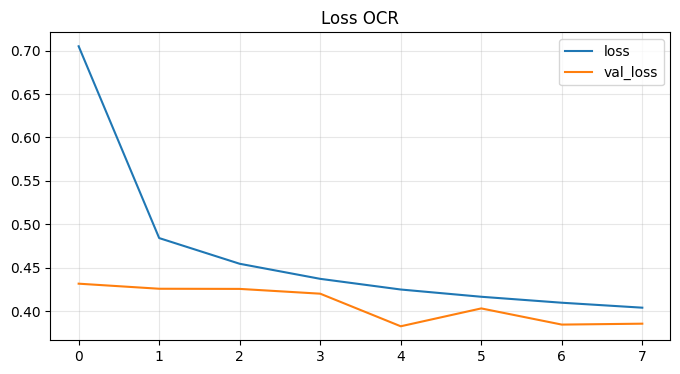

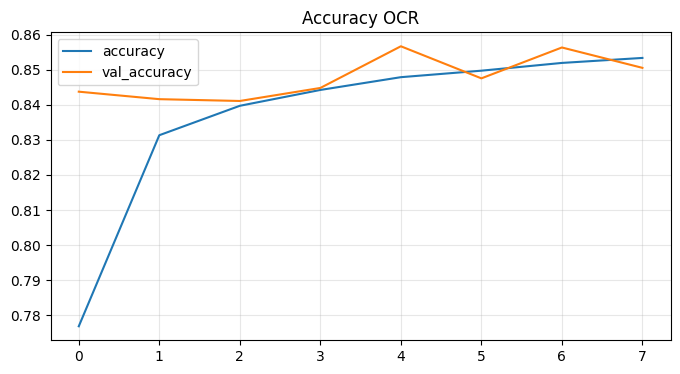

Test loss: 0.3766
Test accuracy: 85.9022%
              precision    recall  f1-score   support

           0       0.65      0.89      0.75      5778
           1       0.62      0.92      0.74      6330
           2       0.95      0.98      0.97      5869
           3       1.00      0.99      0.99      5969
           4       0.98      0.96      0.97      5619
           5       0.95      0.94      0.94      5190
           6       0.97      0.99      0.98      5705
           7       0.99      0.99      0.99      6139
           8       0.98      0.98      0.98      5633
           9       0.92      0.98      0.95      5686
           A       0.94      0.97      0.96      1062
           B       0.93      0.96      0.94       648
           C       0.78      0.90      0.83      1739
           D       0.81      0.94      0.87       779
           E       0.95      0.98      0.96       851
           F       0.76      0.95      0.85      1440
           G       0.92      0.92      

,reel,predit,n
340,O,0,2439
617,l,1,1905
272,I,1,1389
12,0,O,493
634,m,M,459
739,u,U,442
35,1,l,416
713,s,S,391
507,c,C,374
670,p,P,344


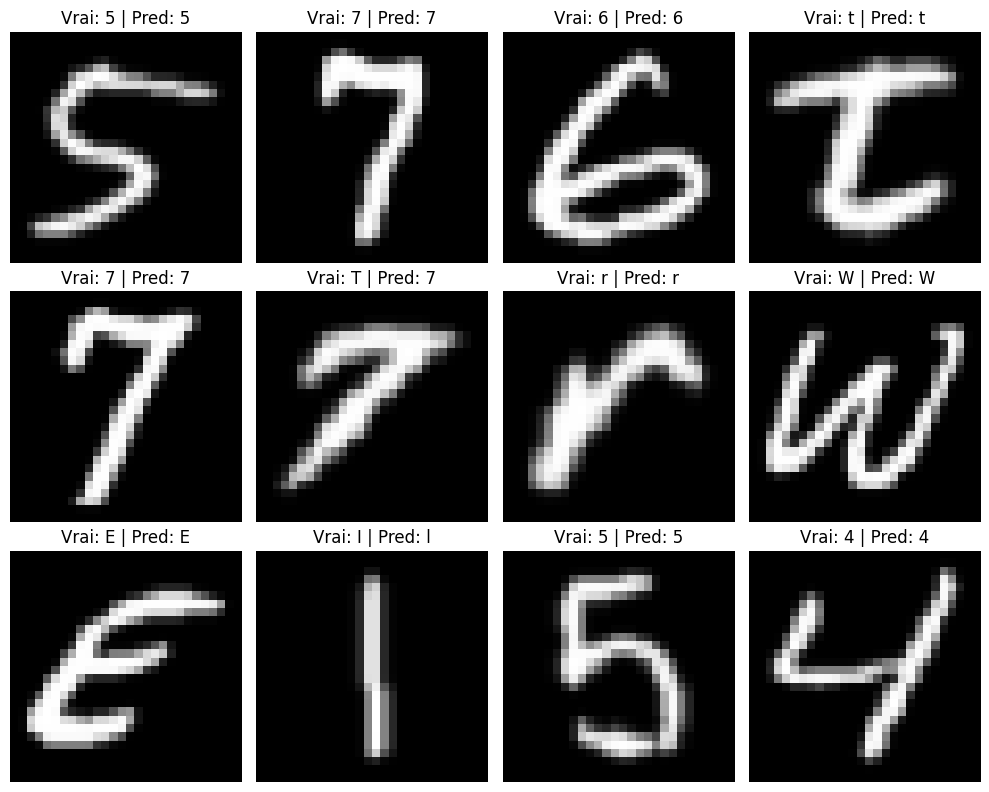

In [4]:
# first model - CNN simple avec data augmentation

test_images_file = DATA_DIR / "test-images-idx3-ubyte"
test_labels_file = DATA_DIR / "test-labels-idx1-ubyte"

test_dataset = MyDataset(test_images_file, test_labels_file)

class_names = [dataset.mapping[i] for i in sorted(dataset.mapping)]
num_classes = len(class_names)

X_train_full = dataset.images.numpy()[..., np.newaxis]
y_train_full = dataset.labels.numpy().astype("int32")
X_test = test_dataset.images.numpy()[..., np.newaxis]
y_test = test_dataset.labels.numpy().astype("int32")

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1,
    random_state=0,
    stratify=y_train_full,
)



batch_size = 256
autotune = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(20000, seed=0).batch(batch_size).prefetch(autotune)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(batch_size).prefetch(autotune)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(autotune)

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.08, 0.08),
], name="augmentation")

def build_ocr_model(input_shape=(28, 28, 1), num_classes=num_classes):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="ocr_cnn")

model = build_ocr_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[early_stopping],
    verbose=1,
)

history_df = pd.DataFrame(history.history)
history_df[["loss", "val_loss"]].plot(figsize=(8, 4), title="Loss OCR")
plt.grid(alpha=0.3)
plt.show()

history_df[["accuracy", "val_accuracy"]].plot(figsize=(8, 4), title="Accuracy OCR")
plt.grid(alpha=0.3)
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")

y_proba = model.predict(test_ds, verbose=0)
y_pred = y_proba.argmax(axis=1)

report = classification_report(
    y_test,
    y_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0,
)
print(report)

cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
confusions = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confusions.append((class_names[i], class_names[j], int(cm[i, j])))

top_confusions = pd.DataFrame(confusions, columns=["reel", "predit", "n"]).sort_values("n", ascending=False).head(15)
display(top_confusions)

sample_idx = np.random.default_rng(0).choice(len(X_test), size=12, replace=False)
sample_images = X_test[sample_idx]
sample_preds = model.predict(sample_images, verbose=0).argmax(axis=1)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax, image, true_idx, pred_idx in zip(axes.ravel(), sample_images, y_test[sample_idx], sample_preds):
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Vrai: {class_names[true_idx]} | Pred: {class_names[pred_idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


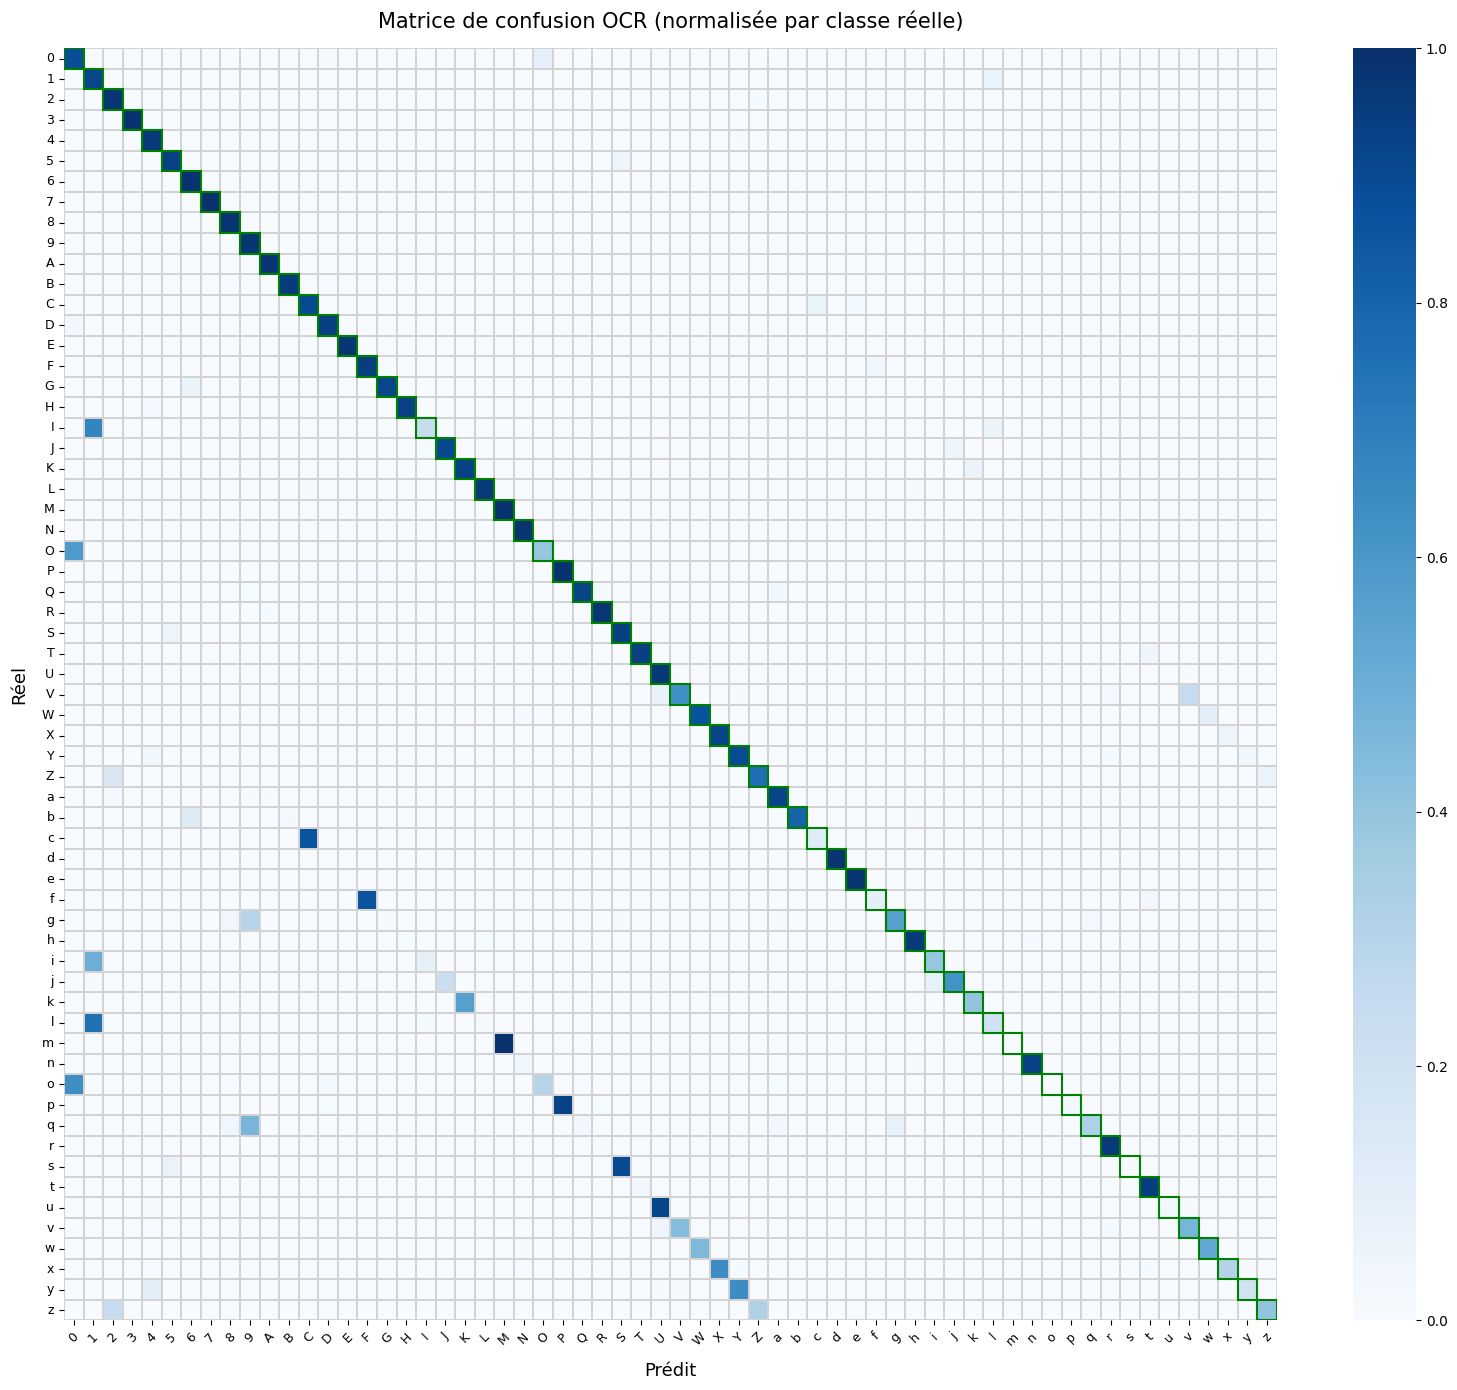

,Réel,Prédit,Nb erreurs,% de la classe réelle
1,O,0,2439,58.7%
2,l,1,1905,75.1%
3,I,1,1389,67.8%
4,0,O,493,8.5%
5,m,M,459,98.9%
6,u,U,442,91.7%
7,1,l,416,6.6%
8,s,S,391,89.5%
9,c,C,374,86.6%
10,p,P,344,93.5%


In [5]:

# matrice de confusion normalisée (couleurs uniquement)
cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_norm,
    annot=False,
    cmap="Blues",
    vmin=0, vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3,
    linecolor="lightgrey",
    ax=ax,
)
ax.set_xlabel("Prédit", fontsize=13, labelpad=10)
ax.set_ylabel("Réel", fontsize=13, labelpad=10)
ax.set_title("Matrice de confusion OCR (normalisée par classe réelle)", fontsize=15, pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

for i in range(len(class_names)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="green", lw=1.5))

plt.tight_layout()
plt.savefig("../Graph/confusion_matrix_ocr.png", dpi=150)
plt.show()

# Top des plus grosses confusions (erreurs uniquement)
confusions = [
    (class_names[i], class_names[j], int(cm[i, j]), round(cm_norm[i, j] * 100, 1))
    for i in range(num_classes)
    for j in range(num_classes)
    if i != j and cm[i, j] > 0
]
top_confusions = (
    pd.DataFrame(confusions, columns=["Réel", "Prédit", "Nb erreurs", "% de la classe réelle"])
    .sort_values("Nb erreurs", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_confusions.index += 1
display(top_confusions.style
    .background_gradient(subset=["Nb erreurs"], cmap="Reds")
    .background_gradient(subset=["% de la classe réelle"], cmap="Oranges")
    .format({"% de la classe réelle": "{:.1f}%"})
)


Model: "ocr_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577,214 (2.20 MB)

 Trainable params: 575,678 (2.20 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/20
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7483 - loss: 0.8174 - val_accuracy: 0.8241 - val_loss: 0.5064
Epoch 2/20
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8044 - loss: 0.5853 - val_accuracy: 0.8367 - val_loss: 0.4630
Epoch 3/20
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8160 - loss: 0.5428 - val_accuracy: 0.8404 - val_loss: 0.4508
Epoch 4/20
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8227 - loss: 0.5166 - val_accuracy: 0.8465 - val_loss: 0.4262
Epoch 5/20
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8275 - loss: 0.4997 - val_accuracy: 0.8460 - val_loss: 0.4270
Epoch 6/20
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8308 - loss: 0.4875 - val_accuracy: 0.8485 - val_loss: 0.4172
Epoch 7/20
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8329 - loss: 0.4788 - val_accuracy: 0.8506 - val_loss: 0.4126
Epoch 8/20
2454/2454 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8350 - loss: 0

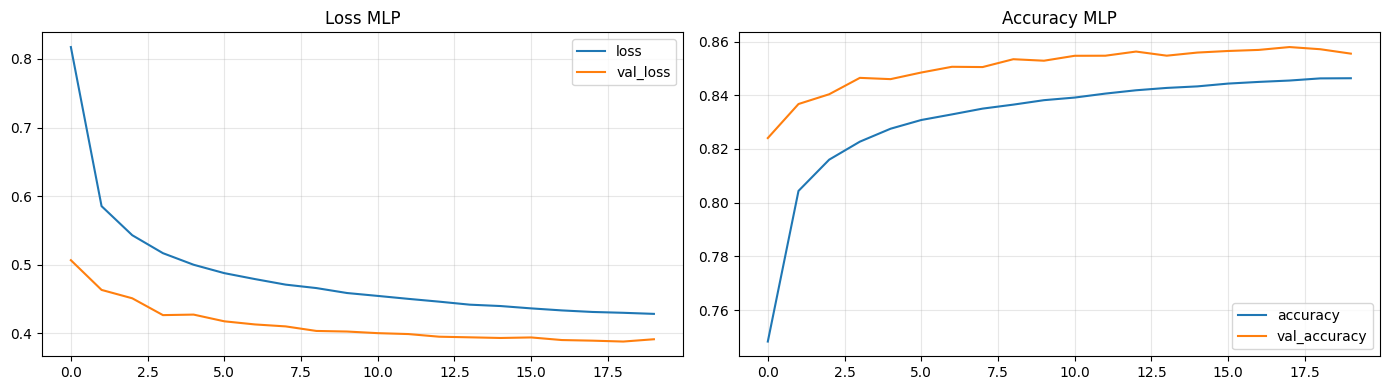

MLP  — Test loss: 0.3854 | Test accuracy: 85.9056%
CNN  — Test loss: 0.3766 | Test accuracy: 85.9022%


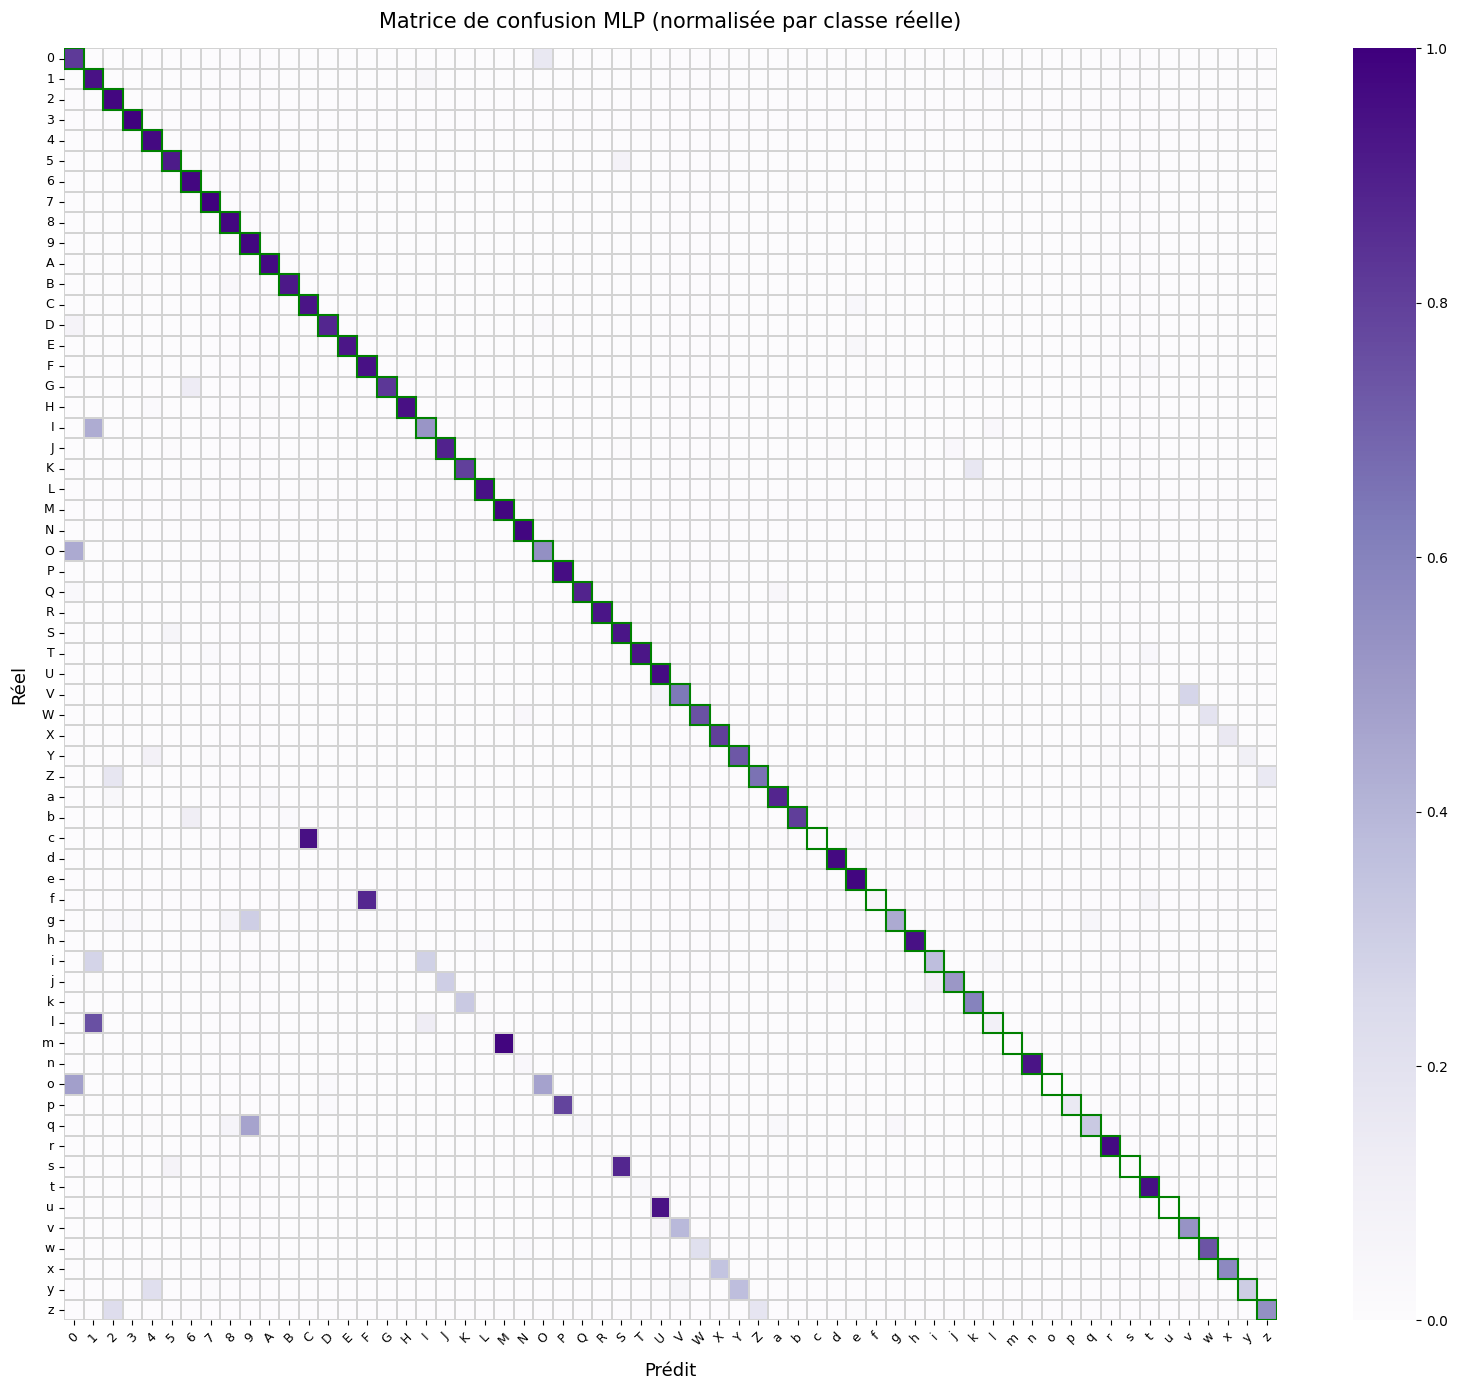

,Réel,Prédit,Nb erreurs,% de la classe réelle
1,l,1,1908,75.3%
2,O,0,1848,44.5%
3,0,O,927,16.0%
4,I,1,894,43.7%
5,m,M,455,98.1%
6,u,U,453,94.0%
7,c,C,409,94.7%
8,5,S,407,7.8%
9,s,S,384,87.9%
10,f,F,349,87.2%


In [6]:

# --- Modèle MLP ---

def build_mlp_model(input_shape=(28, 28, 1), num_classes=num_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="ocr_mlp")

mlp_model = build_mlp_model()
mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
mlp_model.summary()

early_stopping_mlp = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
)

history_mlp = mlp_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping_mlp],
    verbose=1,
)

# Courbes d'apprentissage
history_mlp_df = pd.DataFrame(history_mlp.history)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
history_mlp_df[["loss", "val_loss"]].plot(ax=axes[0], title="Loss MLP")
history_mlp_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Accuracy MLP")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Évaluation
mlp_loss, mlp_accuracy = mlp_model.evaluate(test_ds, verbose=0)
print(f"MLP  — Test loss: {mlp_loss:.4f} | Test accuracy: {mlp_accuracy:.4%}")
print(f"CNN  — Test loss: {test_loss:.4f} | Test accuracy: {test_accuracy:.4%}")

# Prédictions et matrice de confusion
y_pred_mlp = mlp_model.predict(test_ds, verbose=0).argmax(axis=1)

cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=np.arange(num_classes))
cm_mlp_norm = cm_mlp.astype(float) / cm_mlp.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_mlp_norm,
    annot=False,
    cmap="Purples",
    vmin=0, vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3,
    linecolor="lightgrey",
    ax=ax,
)
ax.set_xlabel("Prédit", fontsize=13, labelpad=10)
ax.set_ylabel("Réel", fontsize=13, labelpad=10)
ax.set_title("Matrice de confusion MLP (normalisée par classe réelle)", fontsize=15, pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)
for i in range(len(class_names)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor="green", lw=1.5))
plt.tight_layout()
plt.savefig("../Graph/confusion_matrix_mlp.png", dpi=150)
plt.show()

# Top confusions MLP
confusions_mlp = [
    (class_names[i], class_names[j], int(cm_mlp[i, j]), round(cm_mlp_norm[i, j] * 100, 1))
    for i in range(num_classes)
    for j in range(num_classes)
    if i != j and cm_mlp[i, j] > 0
]
top_confusions_mlp = (
    pd.DataFrame(confusions_mlp, columns=["Réel", "Prédit", "Nb erreurs", "% de la classe réelle"])
    .sort_values("Nb erreurs", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_confusions_mlp.index += 1
display(top_confusions_mlp.style
    .background_gradient(subset=["Nb erreurs"], cmap="Reds")
    .background_gradient(subset=["% de la classe réelle"], cmap="Oranges")
    .format({"% de la classe réelle": "{:.1f}%"})
)
